# 崖歩き課題を例にした強化学習のコード

In [1]:
%matplotlib inline
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from collections import Counter
from copy import deepcopy as cp

In [2]:
state = [[0 for _ in range(12)] for _ in range(8)]


In [3]:
state

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]

## 強化学習の課題に必要なもの
- 課題環境 (Env): 状態と報酬を与える
- エージェント (強化学習する)
- 実行関数

In [4]:
# 崖歩き課題環境を作成
class Env(object):
  """Glid World Environment class

  param
  -----
  post_coordinates(tuple(int, int)):
    Agent 初期位置
  pos_goal(tuple(int, int)):
    ゴール位置

  attr
  -----
  _size(dict):
    glid サイズ
  _state(list(list(int))):
    二次元list、状態を管理
  _coordinates(tuple(int, int)):
    Environment上のAgentの位置 （座標）
  _s(tuple(int, int)):
    現在の状態 (Agentの位置)
  _goal(tuple(int, int)):
    ゴールの位置
  """
  def __init__(self, post_coordinates=(0, 7), pos_goal=(11, 7)):
    self._size = {'width': 12, 'height': 8}
    self._state = [[0 for _ in range(self._size['height'])] for _ in range(self._size['width'])]

    self._coordinates = post_coordinates
    self._s = post_coordinates
    self._goal = pos_goal

  def init_episode(self):
    """Envの episode ごとのリセット関数"""
    coordinate_x, coordinate_y = self._s
    gl_x, gl_y = self._goal
    self._coordinates = self._s
    self._state[coordinate_x][coordinate_y] = 1
    self._state[gl_x][gl_y] = 9

    for i in range(1, 11):
      self._state[i][7] = 5

  @property
  def width(self):
    return self._size['width']

  @property
  def height(self):
    return self._size['height']

  def _limit_pos(self, pos, direct):
    """Agentの移動範囲制御"""
    if pos < 0:
        return 0
    if pos > self._size[direct] - 1:
        return self._size[direct] - 1

    return pos
  def get_state(self):
    """現在状態の取得"""
    return self._coordinates

  def update(self, action):
    """Environmentの更新
    学習Agent が選択した行動を反映し、報酬と次状態を返す
    """
    dif_x, dif_y = action
    coordinate_x, coordinate_y = self._coordinates

    r = 0
    term = False
    self._state[coordinate_x][coordinate_y] = 0

    coordinate_x = self._limit_pos(coordinate_x + dif_x, 'width')
    coordinate_y = self._limit_pos(coordinate_y + dif_y, 'height')

    s_post = (coordinate_x, coordinate_y)

    #ゴールに到達した時にの報酬
    if self._state[coordinate_x][coordinate_y] == 9:
      r = 1
      term = True
    elif self._state[coordinate_x][coordinate_y] == 5:
      r = -10000
      coordinate_x, coordinate_y = self._s
    else:
      r = -1

    self._coordinates = (coordinate_x, coordinate_y)
    self._state[coordinate_x][coordinate_y] = 1

    return r, s_post, term

  def print_anim(self):
    """画像の生成用"""
    plt.xlim(0, self.width)
    plt.ylim(self.height, 0)
    rows = np.arange(self.width+ 1)
    cols = np.arange(self.height + 1)
    X, Y = np.meshgrid(rows, cols)
    C = list(map(list, zip(*self._state)))
    im = plt.pcolor(X, Y, C, cmap=plt.cm.gray_r)
    plt.grid(True, which='both', axis='both', linestyle='-', color='k')
    plt.show()
    return im

In [5]:
# 行動方策一覧

# ランダムに選ぶ方策
def select_random(Q, state, actions, dummy=None):
  action_selected = random.choice(actions)
  return action_selected

# 必ず最も高いQ値の高い行動を選ぶ方策
def select_greedy(Q, state, actions, dummy=None):
  """Greedy選択関数"""
  Qvalues = np.array([Q[state, action] for action in actions])
  idx = np.where(Qvalues == Qvalues.max())
  if len(idx[0]) > 1:
    action_selected = actions[random.choice(idx[0])]
  else:
    action_selected = actions[idx[0][0]]
  return action_selected

# epsilon-greedy 方策
def e_greedy(Q, state, actions, eps=0.1):
  """εGreedy選択、εをしきい値として活用(Greedyな行動)と探索(ランダム行動)を切り替え、行動を返す"""
  if random.random() < eps:
      # 行動をランダム選択
      action_selected = select_random(Q, state, actions)
  else:
    action_selected = select_greedy(Q, state, actions)
  return action_selected

# softmax 方策
def softmax(Q, state, actions, tau=1.0):
  """Softmax選択"""
  Qvalues = np.array([Q[state, action] for action in actions])
  p_boltzmann = dist_boltzmann(Qvalues, tau)
  a = actions[np.random.choice(len(actions), p=p_boltzmann)]
  return a

# softmax 方策に必要なQ値と温度パラメータtauに応じたboltzmann分布を生成する関数
def dist_boltzmann(Q, tau):
  """Boltzmann 分布　= Softmax変換関数"""
  trQ = np.exp(Q - np.max(Q))/tau
  return trQ / trQ.sum(axis=0)

# ランダムに選ぶ分布
def random_distribution(Q, state, actions, dummy=None):
  up = 1/4
  down = 1/4
  left = 1/4
  right = 1/4
  return up, down, left, right


# 必ず最も高いQ値の高い行動を選ぶ分布
def greedy_distribution(Q, state, actions, dummy=None):
  """Greedy選択関数"""
  Qvalues = np.array([Q[state, action] for action in actions])

  idx = np.where(Qvalues == Qvalues.max())
  if len(idx[0]) > 1:
    action_selected = actions[random.choice(idx[0])]
  else:
    action_selected = actions[idx[0][0]]

  actionprop = [
    1 if action == action_selected else 0
    for action in actions
  ]
  
  return actionprop[0], actionprop[1], actionprop[2], actionprop[3]

# epsilon-greedy 方策
def e_greedy_distribution(Q, state, actions, eps=0.1):
  """εGreedy選択、εをしきい値として活用(Greedyな行動)と探索(ランダム行動)を切り替え、行動を返す"""
  if random.random() < eps:
    # 行動をランダム選択
    action_distribution = random_distribution(Q, state, actions)
  else:
    action_distribution = greedy_distribution(Q, state, actions)
  return action_distribution

# softmax分布
def softmax_distribution(Q, state, actions, tau=1.0):
  """Softmax選択"""
  Qvalues = np.array([Q[state, action] for action in actions])
  p_boltzmann = dist_boltzmann(Qvalues, tau)
  return p_boltzmann[0], p_boltzmann[1], p_boltzmann[2], p_boltzmann[3]

# softmax 方策に必要なQ値と温度パラメータtauに応じたboltzmann分布を生成する関数
def dist_boltzmann(Q, tau):
  """Boltzmann 分布　= Softmax変換関数"""
  trQ = np.exp(Q - np.max(Q))/tau
  return trQ / trQ.sum(axis=0)



In [6]:
def sim(epi, env, agent):
  """シミュレーションの主要部

  param
  -----
  epi(int):
    エピソード数
  param(tuple):
    Agentの学習パラメータ
  Env(Env):
    環境
  Agent(BaseAgent):
    学習Agent

  """
  env = env
  agent = agent
  episode = epi

  count = Counter() #行動選択の偏り確認用カウンター
  steps = [] # ゴール到達までにかかったstep数保存用

  # 描画アニメ用
  fig = plt.figure()
  ims = []

  state_print = False
  for ep in range(episode):
      print(f'episode[{ep}]')
      turn = 0
      term = False
      env.init_episode()
      agent.init_episode()
      if state_print:
          im = env.print_anim()
          ims.append([im])

      #エピソード主要部、終端状態までループ
      while(not term):
          s = env.get_state() # 環境から状態を観測
          a = agent.select_action(s) # エージェントが行動選択
          if state_print:
              print(f'agent select {a}')
          r, sd, term = env.update(a) # 環境を更新(報酬と次状態と終端か否か)
          agent.update(r, sd, term) # Q 値を更新

          count[a] += 1 # 行動選択の偏り確認用

          if state_print:
              print(f'turn:{turn}')
              im = env.print_anim()
              ims.append([im])

          turn += 1
#       print(f'terminal! erapsed:{turn}[turn]')
      steps.append(turn)

      # 最後はeval 用
      if ep == episode - 2:
          state_print = True
          agent._behavior_policy = select_greedy

  # gitアニメーションとして保存
#     ani = animation.ArtistAnimation(fig, ims, blit=True, interval=1000, repeat_delay=1000)
#     ani.save("test.gif", writer='imagemagick')
  agent.print_optimal()
  return steps

In [7]:
# エージェントのベースモデル
## 継承して update 関数を実装して使う
class BaseAgent(object):
  """glid world Agent class

  param
  -----
  width(int): default: 7
    glid width
  height(int): default: 7
    glid height
  param(tuple): default: (0.1, 0.9, 0)
    RL learning parameters: alpha, gammma, epsilon
  policy(string): default: Q
    RL Policy: Q epsilon greedy, Q softmax, sarsa epsilon greedy, sarsa softmax
    Q: policy off(behavior != estimation)
    sarsa: policy on(behavior == estimation)
  R(float): default: 0.99
    garbage

  attr
  -----
  _last_action(tuple(int, int)):
    最後に行った行動、学習時に用いる
  _alpha(float):
    学習率
  _gammma(float):
    減衰率
  _eps(float):
    εGreedy時のランダム行動しきい値
  _current_s(tuple(int, int)):
    現在の状態、今回の場合中身はエージェントの位置座標が保存されている(他に変化する情報がないため)
  _action(list(tuple)):
    行動リスト、エージェントの行動として、x座標とy座標に加算する値のTupleが上下左右として入っている
  _Q(dict(float):
    Q値、状態行動対の文字列をキー、それに対応する価値をvalueとし、0で初期化
  _count_action(Counter):
    各行動をどれくらい行ったかをCounterでカウント、使途はない
  _behavior_policy(function):
    挙動方策に何を用いるか、soft方策(各状態を十全に探索できる)である必要がある
  _estimation_policy(function):
    推定方策に何を用いるか
  """
  def __init__(self, width=7, height=7, param=(0.1, 0.9, 0.0), behavior_policies=None, policy_rate=None, name='Q_eg'):
    up = (0, -1) # 上に行く行動
    down = (0, 1) # 下に行く行動
    left = (-1, 0) # 左に行く行動
    right = (1, 0) # 右に行く行動

    self._height = height
    self._width = width

    self._last_action = None
    self._update_action = None
    self._alpha = param[0] #学習率
    self._gamma = param[1] #割引率
    self._eps = param[2] # epsilon (探索率初期値)
    self._tau = 1.0 # 温度パラメータ

    self._current_s = None
    self._update_s = None
    self._actions = [up, down, left, right]
    self._Q = {((i, j), action): 0 for i in range(width) for j in range(height) for action in self._actions}
    self._count_action = Counter()
    self._pre_r = None

    if behavior_policies is None:
      behavior_policies = [greedy_distribution]

    if policy_rate is None:
      policy_rate = [1.0]
      
    if len(behavior_policies) != len(policy_rate):
       raise ValueError("長さが違う")
    
    rates = np.array(policy_rate)
    rates = rates / rates.sum()

    self._behavior_policies = behavior_policies
    self._policy_rate = rates
    # 学習アルゴリズムによって方策を切り替える
    # self._behavior_policy = behavior_policies # 実際に実行した行動が格納されている
    self._estimation_policy = select_greedy # 最大のQ値の行動が格納されている

  @property
  def eps(self):
    return self._eps

  @eps.setter
  def eps(self, eps):
    self._eps = eps

  @property
  def tau(self):
    return self._tau

  @tau.setter
  def tau(self, tau):
    self._tau = tau

  def init_episode(self):
      self._current_s = None
      self._update_s = None
      self._last_action = None
      self._update_action = None
      self._pre_r = None

      # self._behavior_policy

  def _mix_distribution(self, s):
    probs = np.zeros(len(self._actions))

    for policy, rate in zip(self._behavior_policies, self._policy_rate):
        probs += np.array(
            policy(
                self._Q,
                s,
                self._actions,
                self._eps
            )
        ) * rate

    probs /= probs.sum()
    return tuple(probs)
  
  def _mix_select(self, s):
    props = self._mix_distribution(s)
    a = self._actions[np.random.choice(len(self._actions), p=props)]
    return a

  def select_action(self, s):
    """挙動方策によって行動を選択し選択行動を返す"""
    self._current_s = s
    # a = self._behavior_policy(self._Q, self._current_s, self._actions, self._eps)
    a = self._mix_select(self._current_s)
    self._count_action[s, a] += 1
    self._last_action = a

    return a

  def _update_param(self):
    """探索パラーメタのアップデート"""
    self._eps = 1.0*self._eps
    self._tau = 1.0*self._tau

  def update(self, r, next_s, term):
    # 継承して実装
    pass


  def print_optimal(self):
    """最適方策(Greedy選択)表示用"""
    action = ['UP', 'DN', 'LT', 'RT']
    for y in range(self._height):
        print('|', end='')
        for x in range(self._width):
            print(f'{select_greedy(self._Q, (x, y), self._actions)}\t', end='')
            print('|', end='')
        print()

## Q 学習エージェント + Epsilon-Greedy

In [8]:
class OffPolicyAgent(BaseAgent):
  """ Off-policy Agetn = Q-learning Agent """

  def _update_param(self):
    """探索パラーメタのアップデート"""
    self._eps = 1.0*self._eps
    self._tau = 1.0*self._tau

  def update(self, r, next_s, term):
    """Q値更新関数
    r(float):
      報酬
    sd(tuple(int, int)):
      次状態
    term(bool):
      終端状態判別フラグ

    """
    buckup_action = self._estimation_policy(self._Q, self._current_s, self._actions, self._eps)


    if self._update_s is not None:
        target = self._pre_r + self._gamma * self._Q[(self._current_s, buckup_action)] - self._Q[(self._update_s, self._update_action)]
        self._Q[(self._update_s, self._update_action)] += self._alpha * target

    if term:
        self._Q[(self._current_s, self._last_action)] += self._alpha * r
        self._update_param() # 終端についたら探索パラメータを更新 (ここでなくてもよい)
    else:
        self._update_s = cp(self._current_s)
        self._update_action = cp(self._last_action)
        self._current_s = next_s
        self._pre_r = cp(r)

episode[0]
episode[1]
episode[2]
episode[3]
episode[4]
episode[5]
episode[6]
episode[7]
episode[8]
episode[9]
episode[10]
episode[11]
episode[12]
episode[13]
episode[14]
episode[15]
episode[16]
episode[17]
episode[18]
episode[19]
episode[20]
episode[21]
episode[22]
episode[23]
episode[24]
episode[25]
episode[26]
episode[27]
episode[28]
episode[29]
episode[30]
episode[31]
episode[32]
episode[33]
episode[34]
episode[35]
episode[36]
episode[37]
episode[38]
episode[39]
episode[40]
episode[41]
episode[42]
episode[43]
episode[44]
episode[45]
episode[46]
episode[47]
episode[48]
episode[49]
episode[50]
episode[51]
episode[52]
episode[53]
episode[54]
episode[55]
episode[56]
episode[57]
episode[58]
episode[59]
episode[60]
episode[61]
episode[62]
episode[63]
episode[64]
episode[65]
episode[66]
episode[67]
episode[68]
episode[69]
episode[70]
episode[71]
episode[72]
episode[73]
episode[74]
episode[75]
episode[76]
episode[77]
episode[78]
episode[79]
episode[80]
episode[81]
episode[82]
episode[83]
ep

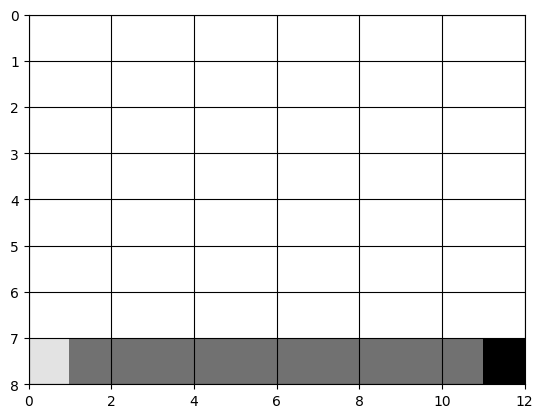

agent select (0, -1)
turn:0


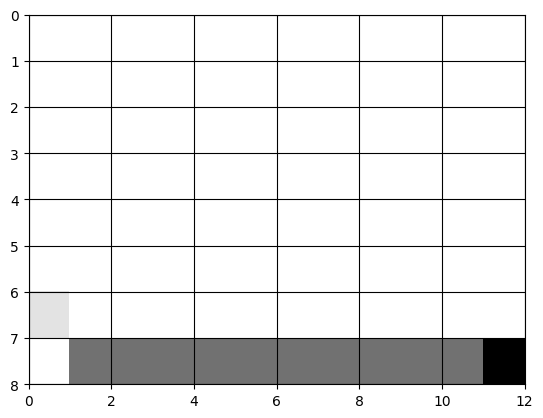

agent select (0, -1)
turn:1


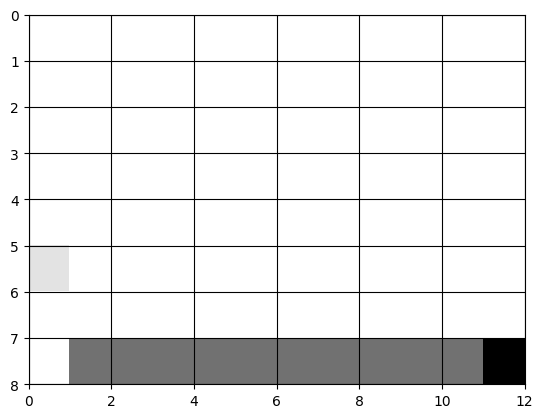

agent select (1, 0)
turn:2


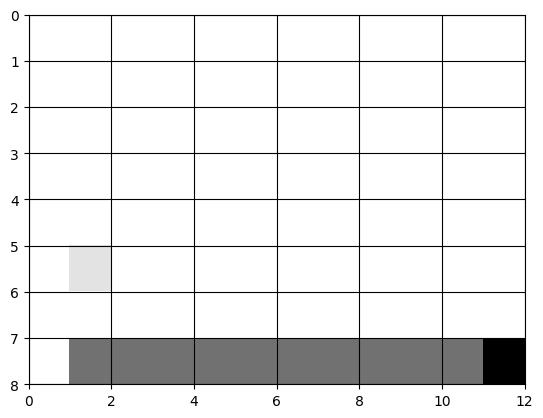

agent select (1, 0)
turn:3


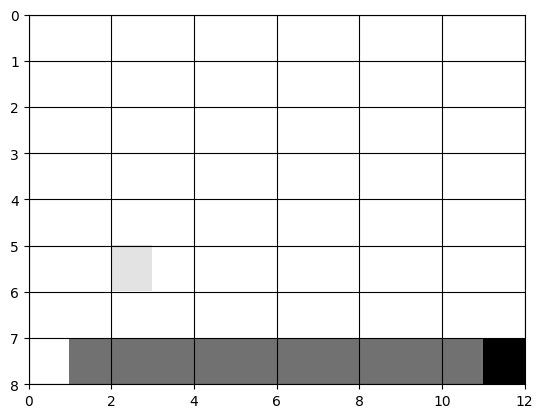

agent select (0, -1)
turn:4


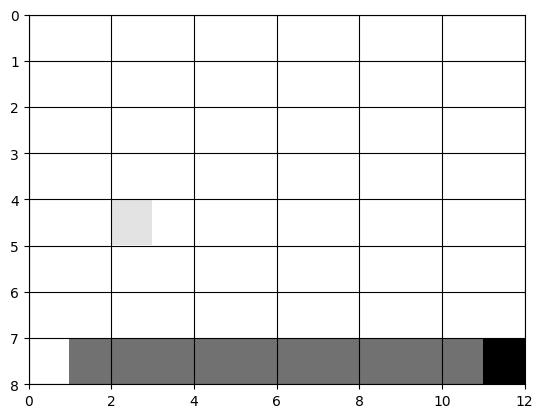

agent select (0, -1)
turn:5


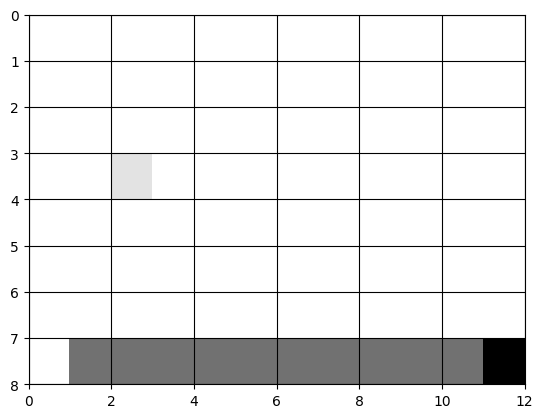

agent select (0, 1)
turn:6


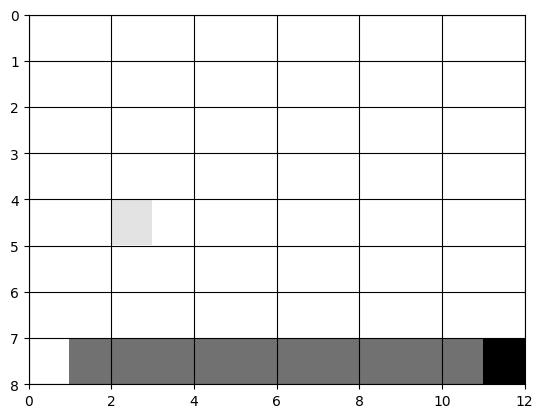

agent select (-1, 0)
turn:7


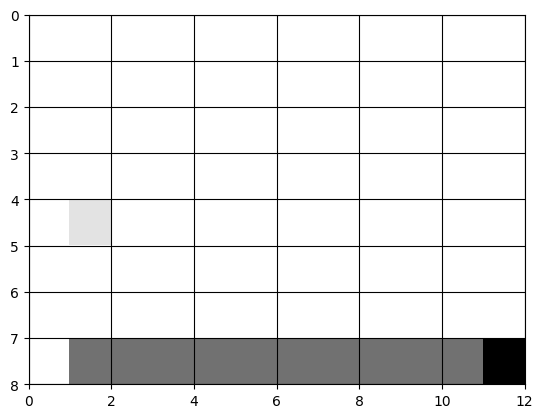

agent select (0, -1)
turn:8


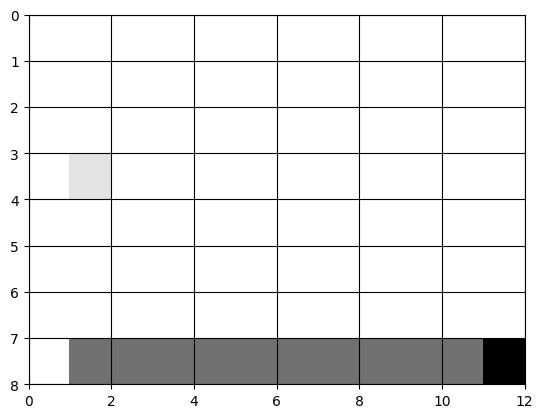

agent select (0, 1)
turn:9


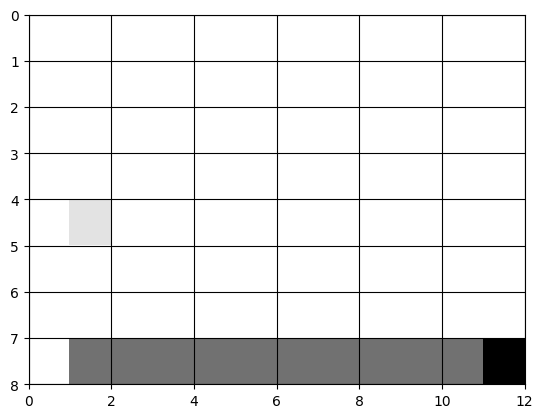

agent select (1, 0)
turn:10


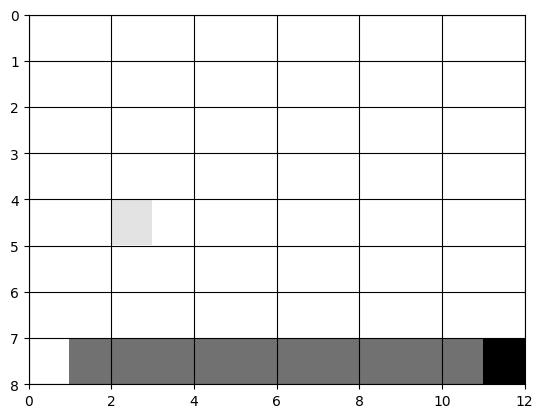

agent select (1, 0)
turn:11


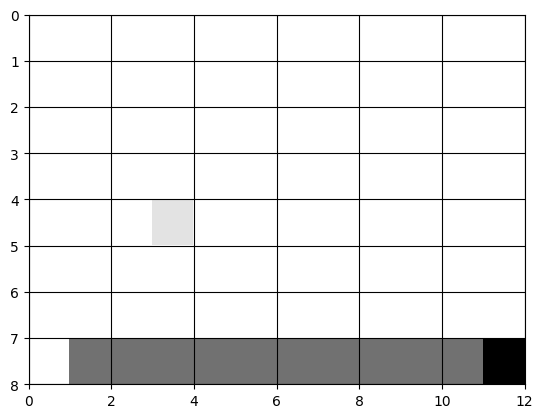

agent select (0, 1)
turn:12


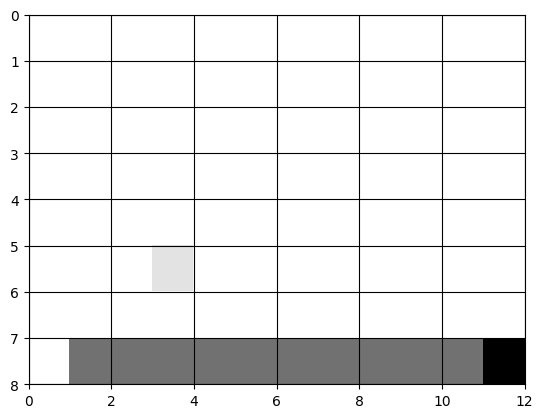

agent select (1, 0)
turn:13


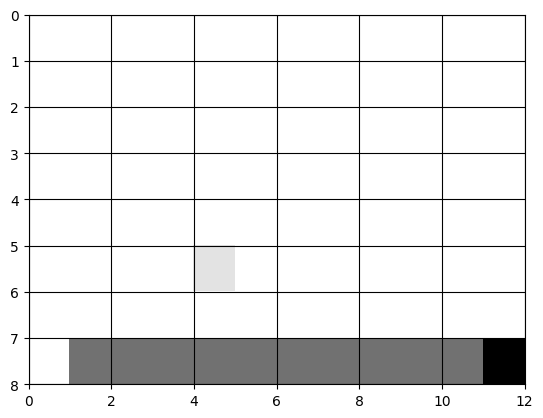

agent select (1, 0)
turn:14


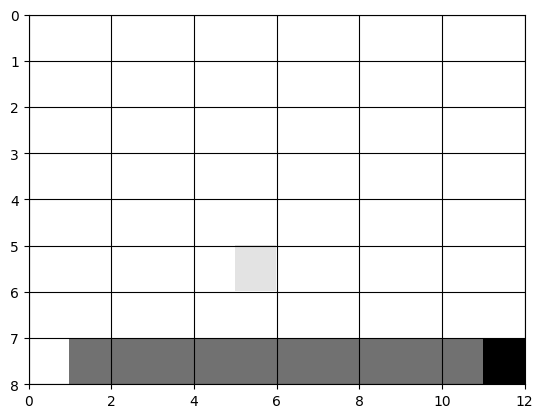

agent select (1, 0)
turn:15


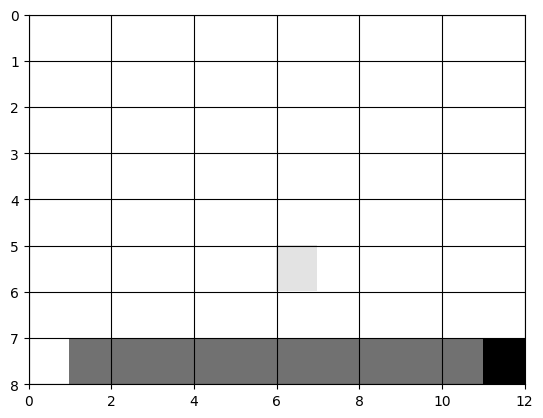

agent select (1, 0)
turn:16


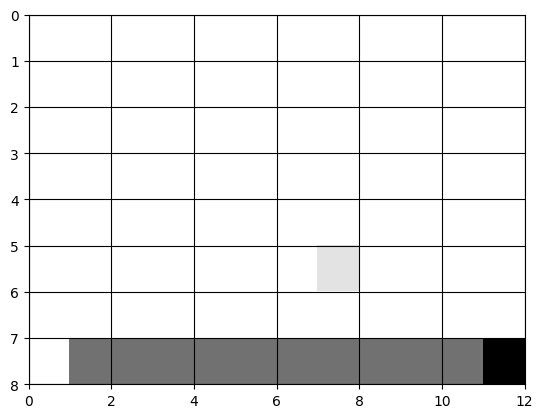

agent select (1, 0)
turn:17


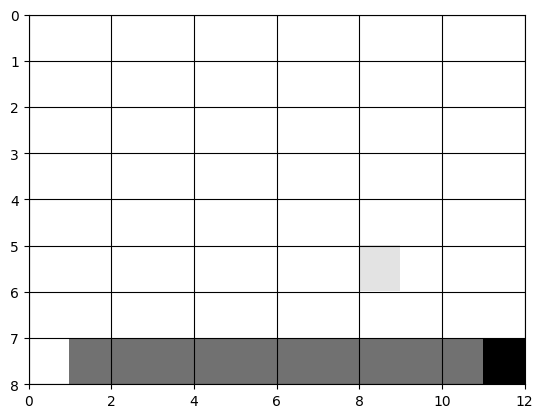

agent select (1, 0)
turn:18


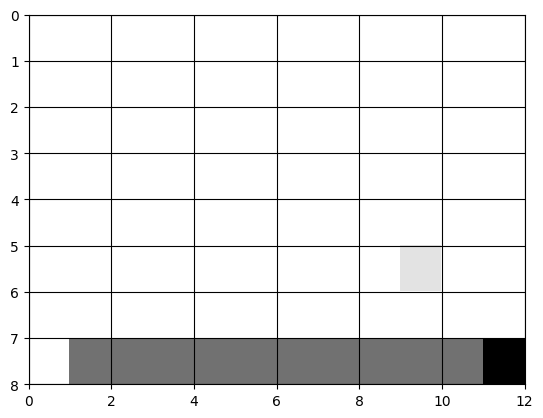

agent select (1, 0)
turn:19


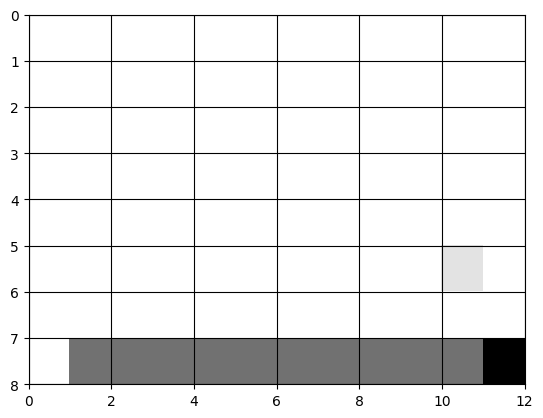

agent select (1, 0)
turn:20


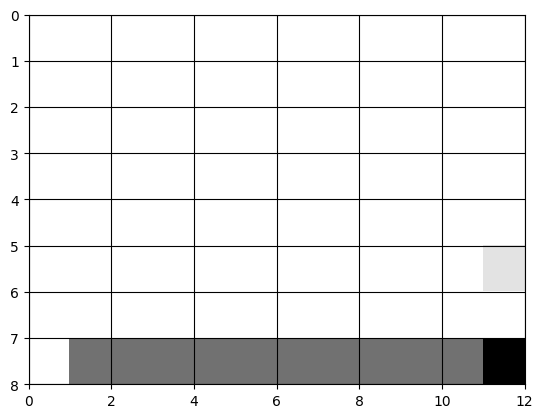

agent select (-1, 0)
turn:21


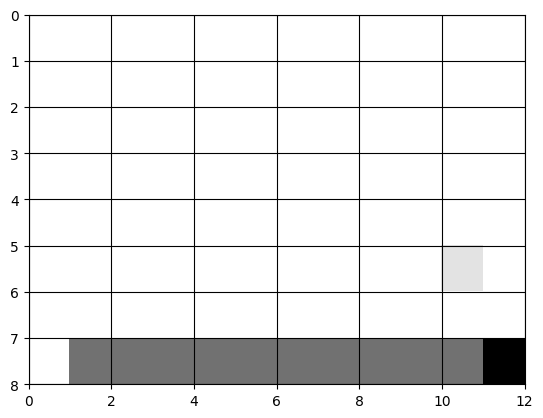

agent select (0, -1)
turn:22


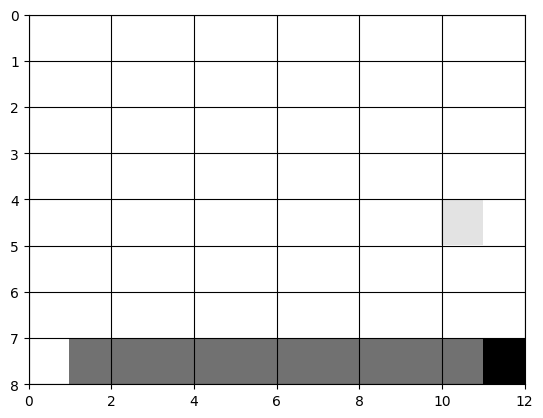

agent select (1, 0)
turn:23


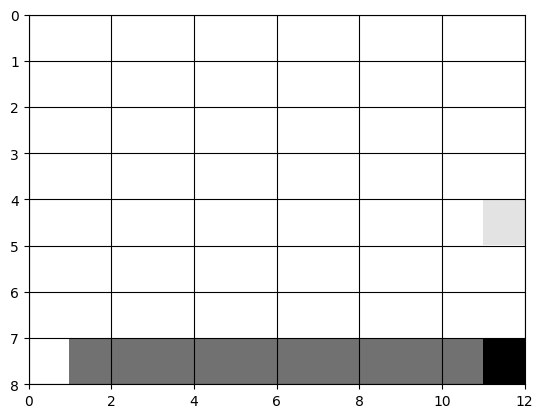

agent select (0, 1)
turn:24


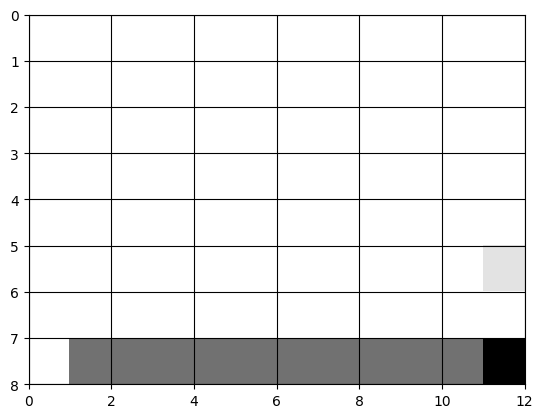

agent select (0, 1)
turn:25


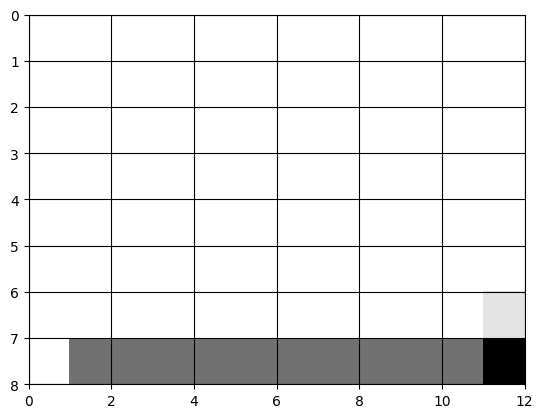

agent select (1, 0)
turn:26


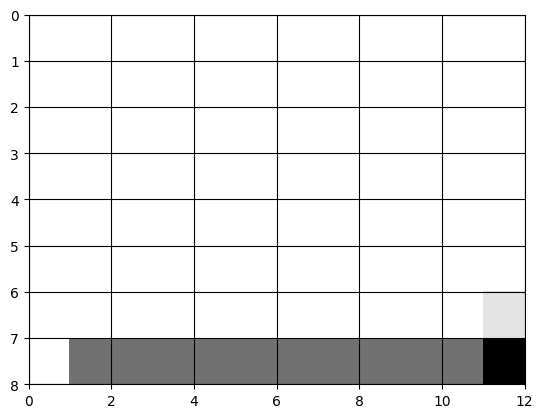

agent select (0, 1)
turn:27


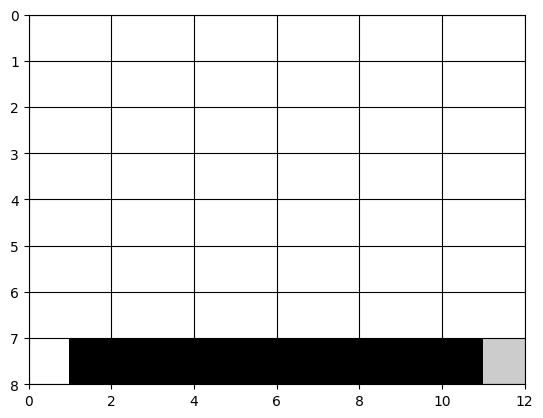

|(1, 0)	|(0, -1)	|(-1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(-1, 0)	|
|(0, -1)	|(-1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, -1)	|(1, 0)	|(-1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, -1)	|(-1, 0)	|(1, 0)	|(-1, 0)	|(1, 0)	|(1, 0)	|(0, -1)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, -1)	|(0, -1)	|(-1, 0)	|(0, -1)	|(-1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, -1)	|(0, 1)	|(1, 0)	|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|
|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|
|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|
|(0, -1)	|(1, 0)	|(0, 1)	|(-1, 0)	|(1, 0)	|(0, 1)	|(-1, 0)	|(0, -1)	|(1, 0)	|(0, 1)	|(1, 0)	|(-1, 0)	|


In [9]:
# main
episode = 200
env = Env()
agent = OffPolicyAgent(env.width, env.height, param=(0.1, 0.9, 0.1), behavior_policies=[random_distribution, greedy_distribution], policy_rate=[1,1],  name='Q+e-greedy')

steps_Q_e_greedy = sim(epi=episode, env=env, agent=agent)

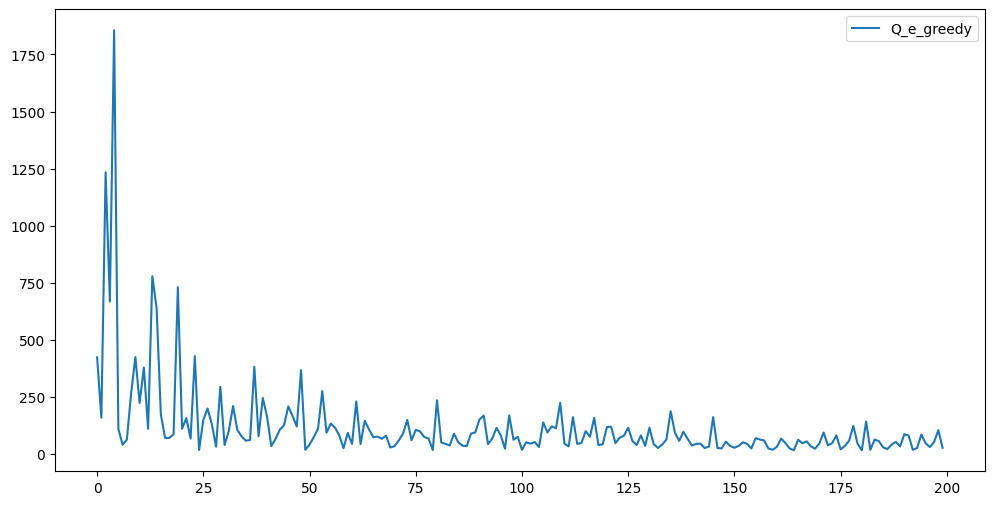

last policy steps
  Q_e_greedy: 	28 steps


In [10]:
# 結果
plt.figure(figsize=(12.0, 6.0))
plt.plot(np.arange(episode), steps_Q_e_greedy)
plt.legend(
    ['Q_e_greedy',
     ],
    loc='upper right'
)
plt.show()
print('last policy steps')
print('  Q_e_greedy: \t{} steps'.format(steps_Q_e_greedy[-1]))

## 方策 On 型 TD 学習 (Sarsa)

In [11]:
class OnPolicyAgent(BaseAgent):
  """ On-policy Agetn = SARSA Agent """

  def _update_param(self):
    """探索パラーメタのアップデート"""
    self._eps = 1.0*self._eps
    self._tau = 1.0*self._tau

  def update(self, r, next_s, term):
    """Q値更新関数
    r(float):
      報酬
    sd(tuple(int, int)):
      次状態
    term(bool):
      終端状態判別フラグ

    """
    buckup_action = self._mix_select(next_s) # ここを書き換える

    if self._update_s is not None:
        target = self._pre_r + self._gamma * self._Q[(self._current_s, buckup_action)] - self._Q[(self._update_s, self._update_action)]
        self._Q[(self._update_s, self._update_action)] += self._alpha * target

    if term:
        self._Q[(self._current_s, self._last_action)] += self._alpha * r
        self._update_param() # 終端についたら探索パラメータを更新 (ここでなくてもよい)
    else:
        self._update_s = cp(self._current_s)
        self._update_action = cp(self._last_action)
        self._current_s = next_s
        self._pre_r = cp(r)

In [12]:
# main
episode = 200
env = Env()
agent = OnPolicyAgent(env.width, env.height, param=(0.1, 0.9, 0.1), behavior_policies=[random_distribution, greedy_distribution], policy_rate=[1,1], name='SARSA+e-greedy')

steps_SARSA_e_greedy = sim(epi=episode, env=env, agent=agent)

episode[0]
episode[1]
episode[2]
episode[3]
episode[4]
episode[5]
episode[6]
episode[7]
episode[8]
episode[9]
episode[10]
episode[11]
episode[12]
episode[13]
episode[14]
episode[15]
episode[16]
episode[17]
episode[18]
episode[19]
episode[20]
episode[21]
episode[22]
episode[23]
episode[24]
episode[25]
episode[26]
episode[27]
episode[28]
episode[29]
episode[30]
episode[31]
episode[32]
episode[33]
episode[34]
episode[35]
episode[36]
episode[37]
episode[38]
episode[39]
episode[40]
episode[41]
episode[42]
episode[43]
episode[44]
episode[45]
episode[46]
episode[47]
episode[48]
episode[49]
episode[50]


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [ ]:
# 結果
plt.figure(figsize=(12.0, 6.0))
plt.plot(np.arange(episode), steps_Q_e_greedy)
# plt.plot(np.arange(episode), steps_Q_softmax)
plt.plot(np.arange(episode), steps_SARSA_e_greedy)
plt.legend(
    ['Q_e_greedy',
     'Q_softmax',
     'SARSA_e_greedy',
     ],
    loc='upper right'
)
plt.show()
print('last policy steps')
print('  Q_e_greedy: \t\t{} steps'.format(steps_Q_e_greedy[-1]))
# print('  Q_softmax: \t\t\t{} steps'.format(steps_Q_softmax[-1]))
print('  SARSA_e_greedy:\t{} steps'.format(steps_SARSA_e_greedy[-1]))

In [ ]:
b=0